In [ ]:
import os

# Replace with your actual token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_1e24e208873a6c7238d75a5372d62bac"

!pip install -q kaggle

In [ ]:
!pip install -U -q kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 23.4 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:51<00:00, 22.2MB/s]



In [ ]:
import zipfile

archive_path = r'/content/dogsvscats.zip'
with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt



In [ ]:
train_DS=keras.utils.image_dataset_from_directory(
    directory=r"/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Validation_DS=keras.utils.image_dataset_from_directory(
    directory=r"/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


***Generators***

In [ ]:
# Normalization layer

def process(image, label):
    image=tf.cast(image/255., tf.float32)
    return image, label

In [ ]:
train_DS=train_DS.map(process)
Validation_DS=Validation_DS.map(process)

In [ ]:
# now create CNN model

In [ ]:
model=Sequential()
model.add(Conv2D(32,
                 kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(256, 256, 3)
                 )
                 )
model.add(MaxPooling2D(pool_size=(2, 2),
                       strides=2,
                       padding='valid'
                       )
                       )

model.add(Conv2D(64,
                 kernel_size=(3, 3),
                 activation='relu',
                 )
                 )
model.add(MaxPooling2D(pool_size=(2, 2),
                       strides=2,
                       padding='valid'
                       )
                       )

model.add(Conv2D(128,
                 kernel_size=(3, 3),
                 activation='relu',
                 )
                 )
model.add(MaxPooling2D(pool_size=(2, 2),
                       strides=2,
                       padding='valid'
                       )
                       )


model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'],

              )

In [ ]:
history=model.fit(train_DS,
          epochs=10,
          validation_data=Validation_DS,
          )
history

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 82ms/step - accuracy: 0.6676 - loss: 0.6064 - val_accuracy: 0.7552 - val_loss: 0.5058
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7800 - loss: 0.4612 - val_accuracy: 0.8014 - val_loss: 0.4258
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8428 - loss: 0.3504 - val_accuracy: 0.7966 - val_loss: 0.4705
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.9014 - loss: 0.2332 - val_accuracy: 0.8110 - val_loss: 0.4777
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9464 - loss: 0.1369 - val_accuracy: 0.7998 - val_loss: 0.6643
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9689 - loss: 0.0839 - val_accuracy: 0.8040 - val_loss: 0.8199
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9773 - loss: 0.0625 - val_accuracy: 0.7972 - val_loss: 0.9147
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.9826 - loss: 0.0550 - 

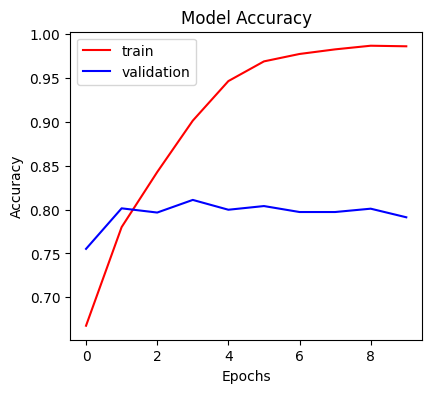

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

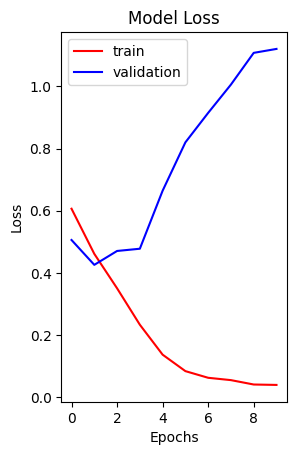

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_img_1=cv2.imread("/content/train/101384156-cat-calm-at-night-632x475_0.webp")
test_image_2=cv2.imread("/content/train/elephant-at-night.webp")
tes_image_3=cv2.imread("/content/train/young-asian-woman-in-loving-embrace-with-her-dog-in-nature.webp")

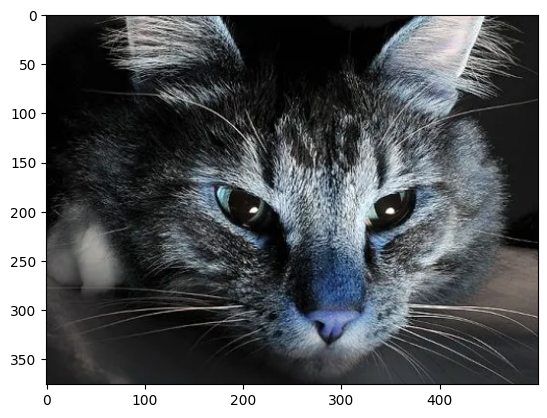

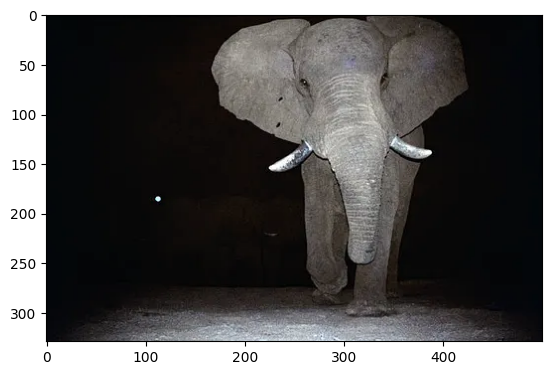

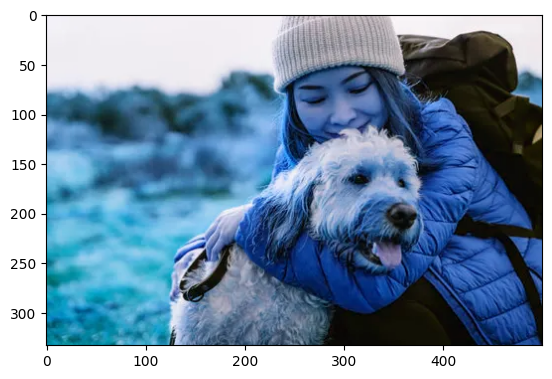

In [ ]:
plt.imshow(test_img_1)
plt.show()
plt.imshow(test_image_2)
plt.show()
plt.imshow(tes_image_3)
plt.show()

In [ ]:
test_image_1=cv2.resize(test_img_1, (256, 256))
test_image_2=cv2.resize(test_image_2, (256, 256))
test_image_3=cv2.resize(tes_image_3, (256, 256))

In [ ]:
test_input_1=test_image_1.reshape((1, 256, 256, 3))
test_input_2=test_image_2.reshape((1, 256, 256, 3))
test_input_3=test_image_3.reshape((1, 256, 256, 3))

In [ ]:
print(model.predict(test_input_1))
print(model.predict(test_input_2))
print(model.predict(test_input_3 ))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
[[1.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[1.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[1.]]
